#### Name: Jariwala Mohit S.
#### Reg No: 2548563
#### subject: DL
#### Lab: CIA-3 program1 CNN architecture

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from collections import Counter

In [ ]:
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

Processing of the CIFAR-10 Dataset

In [ ]:
dataset = torchvision.datasets.CIFAR10(
root='./data',
train=True,
download=True,
transform=transform
)
classes = dataset.classes

100%|██████████| 170M/170M [00:05<00:00, 28.9MB/s]


In [ ]:
selected_images = []
selected_labels = []
seen_classes = set()
for img, label in dataset:
  if label not in seen_classes:
    selected_images.append(img)
    selected_labels.append(label)
    seen_classes.add(label)
  if len(seen_classes) == 10:
      break
images = torch.stack(selected_images)
labels = torch.tensor(selected_labels)

print("Selected Classes:")
for i in labels:
  print(classes[i])

Selected Classes:
frog
truck
deer
automobile
bird
horse
ship
cat
dog
airplane


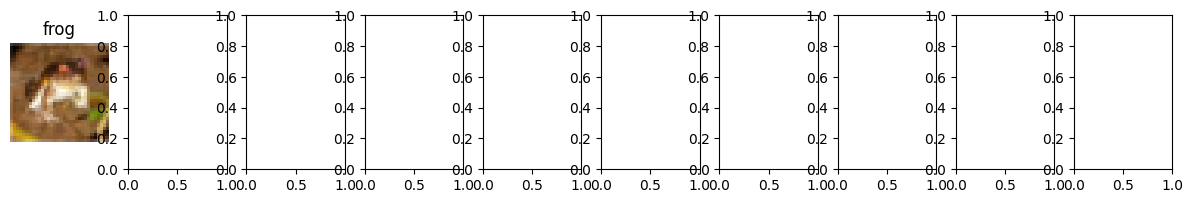

In [ ]:
fig, axes = plt.subplots(1,10, figsize=(15,2))
for i in range(10):
  img = images[i] / 2 + 0.5
  img = img.permute(1,2,0)
  axes[i].imshow(img)
  axes[i].set_title(classes[labels[i]])
  axes[i].axis('off')
  plt.show()

In [ ]:
dataset_small = torch.utils.data.TensorDataset(images, labels)
train_loader = torch.utils.data.DataLoader(
  dataset_small,
  batch_size=5,
  shuffle=True
)

- The CIFAR-10 images were first converted into tensors using ToTensor() so they can be processed by PyTorch.
- The images were normalized using Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)).
- This normalization scales pixel values from the range [0,1] to approximately [-1,1].
- Normalization helps make the training more stable and allows the neural network to converge faster.
- It also prevents some features to be very large or very small. (prevents the vanishing gradient descent and exploding gradient
descent problem)

## CNN Architecture

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.fc1 = nn.Linear(32*8*8,128)
        self.fc2 = nn.Linear(128,10)
        self.relu = nn.ReLU()
    def forward(self,x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        feature_maps = x
        x = x.view(x.size(0),-1)
        flattened = x
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x, feature_maps, flattened

- The CNN model consists of two convolutional layers and after that, pooling layers and fully connected layers.
- The first convolution layer takes 3 input channels (RGB image) and produces 16 feature maps using a 3×3 filter.
- A ReLU activation function is there so it will introduce non-linearity.
- A MaxPooling layer with size 2×2 reduces the dimersions and extracts only the important features, it also helps in preventing
overfitting.
- The second convolution layer takes 16 channels and produces 32 feature maps using a 3×3 filter.
- Another ReLU activation and MaxPooling layer are applied.
- The resulting feature maps are flattened into a one-dimensional vector.
- This flattened vector is passed through a fully connected layer with 128 neurons.
- The final fully connected layer outputs 10 neurons corresponding to the 10 CIFAR-10 classes.

In [ ]:
model = CNN()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

- CrossEntropyLoss was used as the loss function.
- This loss function is suitable for multi-class classification problems such as CIFAR-10.
- Here, we have 10 different classes, so it is the most suitable.
- It compares the predicted class probabilities with the true labels and measures the classification error.
- The Adam optimizer was used for training.
- Adam combines the advantages of momentum and adaptive learning rates, allowing faster and more stable convergence
during training.

In [ ]:
epochs = 20
for epoch in range(epochs):
  running_loss = 0
# All changes saved
  for images_batch, labels_batch in train_loader:
    optimizer.zero_grad()
    outputs, feature_maps, flattened = model(images_batch)
    loss = criterion(outputs, labels_batch)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {running_loss:.4f}")

Epoch 1 Loss: 2.2829
Epoch 1 Loss: 4.7341
Epoch 2 Loss: 2.1985
Epoch 2 Loss: 4.4323
Epoch 3 Loss: 2.0670
Epoch 3 Loss: 4.1414
Epoch 4 Loss: 1.9037
Epoch 4 Loss: 3.7879
Epoch 5 Loss: 1.7708
Epoch 5 Loss: 3.3488
Epoch 6 Loss: 1.2806
Epoch 6 Loss: 2.8730
Epoch 7 Loss: 1.2322
Epoch 7 Loss: 2.2799
Epoch 8 Loss: 0.7879
Epoch 8 Loss: 1.6753
Epoch 9 Loss: 0.7046
Epoch 9 Loss: 1.1673
Epoch 10 Loss: 0.4911
Epoch 10 Loss: 0.7275
Epoch 11 Loss: 0.2437
Epoch 11 Loss: 0.4026
Epoch 12 Loss: 0.1475
Epoch 12 Loss: 0.1975
Epoch 13 Loss: 0.0226
Epoch 13 Loss: 0.0880
Epoch 14 Loss: 0.0335
Epoch 14 Loss: 0.0502
Epoch 15 Loss: 0.0174
Epoch 15 Loss: 0.0253
Epoch 16 Loss: 0.0053
Epoch 16 Loss: 0.0130
Epoch 17 Loss: 0.0063
Epoch 17 Loss: 0.0080
Epoch 18 Loss: 0.0034
Epoch 18 Loss: 0.0051
Epoch 19 Loss: 0.0010
Epoch 19 Loss: 0.0034
Epoch 20 Loss: 0.0021
Epoch 20 Loss: 0.0026


In [ ]:
correct = 0
total = 0
with torch.no_grad():
# All changes saved
  outputs, feature_maps, flattened = model(images)
  _, predicted = torch.max(outputs,1)
  total += labels.size(0)
  correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Validation Accuracy:", accuracy,"%")

Validation Accuracy: 100.0 %


- The model achieved a validation accuracy of 100%.
- This means that the model correctly classified all the validation samples that we took earilier.
- Since the dataset contained only 10 images, the model may have memorized the training data.
- To diagnose overfitting, we can compare training accuracy with validation accuracy on a larger dataset.
- If training accuracy is very high but validation accuracy is low, the model is overfitting.
- If both training and validation accuracy are low, the model is underfitting.

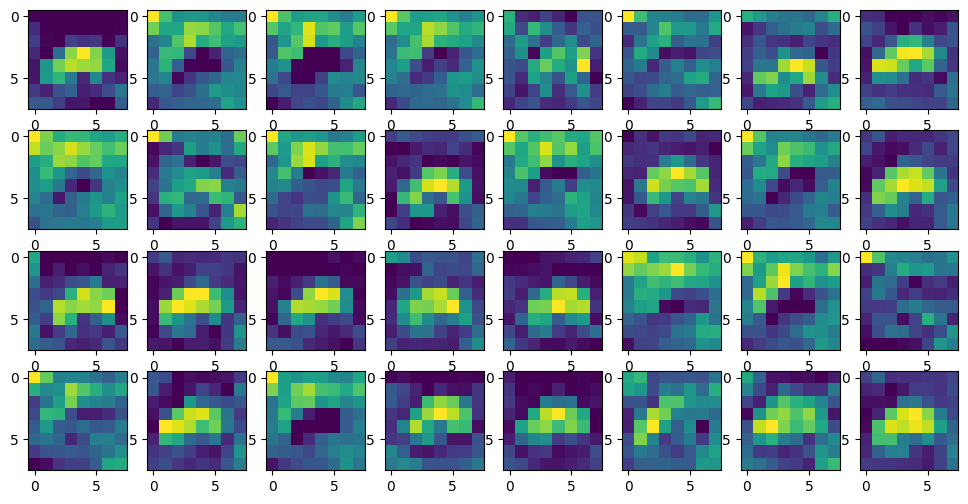

In [ ]:
feature_maps = feature_maps[0].detach()
fig, axes = plt.subplots(4,8, figsize=(12,6))
for i, ax in enumerate(axes.flat):
  if i < feature_maps.shape[0]:
    ax.imshow(feature_maps[i], cmap='viridis')

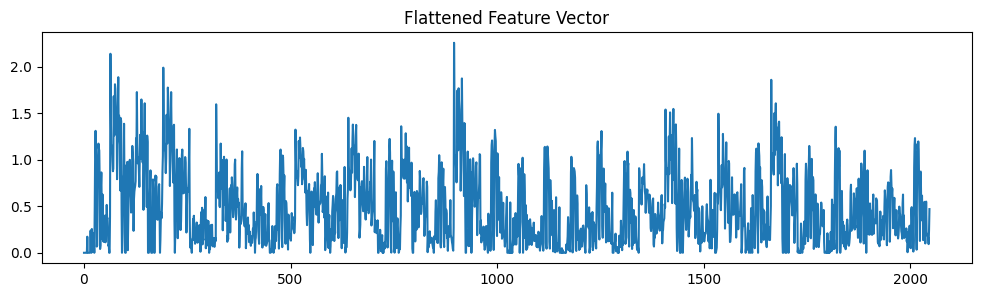

Flattened vector shape: (2048,)


In [ ]:
flattened_vector = flattened[0].detach().numpy()
plt.figure(figsize=(12,3))
plt.plot(flattened_vector)
plt.title("Flattened Feature Vector")
plt.show()
print("Flattened vector shape:", flattened_vector.shape)

- After the convolution and pooling operations, the feature maps were flattened into a vector.
- The flattened vector had a size of 2048 elements.
- This vector represents the extracted features learned by the convolution layers.
- The visualization shows how the CNN converts image information into a numerical feature representation that can be used by
the fully connected layers for classification.

## In order to Increase the Accuracy
- because Here the problem is that we are getting perfect accuracy, our model might be memorizing things instead of learning well

### possible improvements can be:
1. Applying regularization
- One improvement would be applying regularization techniques such as Dropout or L2 regularization to reduce overfitting.
- Since the model was trained on a very small dataset, it may memorize the training samples instead of learning general
patterns.
- Regularization techniques help the model generalize better to unseen data.

2. Data Augmentation
- Another improvement would be using data augmentation techniques such as random flipping, rotation, or cropping.
- Data augmentation artificially increases the size and diversity of the training dataset.
- This helps the model learn features with different angles and reduces the risk of overfitting.